# Notebook 02: Lattice Navigation

**Learning objectives:**
- Map between lattice coordinates $(x,y,z,t)$ and linear indices
- Understand periodic boundary conditions
- Navigate forward and backward on the lattice
- Build precomputed neighbor tables for efficiency
- Visualize the even/odd checkerboard structure

**Prerequisites:** Notebook 01

**Key functions:** `su2.p2i()`, `i2p()`, `mupi()`, `mdowni()`, `getMups()`, `getMdns()`, `parity()`

In [1]:
from notebook_utils import setup_paths
setup_paths()

import numpy as np
import matplotlib.pyplot as plt
import su2

/home/zeke/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Lattice Dimensions and Volume

A 4D lattice with dimensions $L_x \times L_y \times L_z \times L_t$
has $V = L_x L_y L_z L_t$ sites. Each site is labeled by coordinates
$(x,y,z,t)$ **or** by a single linear index $i \in [0, V)$.

This is the standard 4D Euclidean lattice setup: positions are integer multiples of the lattice spacing, $x_\mu = a\,n_\mu$ (Eq. 10.12 in High Energy Physics Essentials), with $n_i \in [0, N_s)$ for the spatial directions and $n_4 \in [0, N_t)$ for the temporal direction.

In [2]:
# La has the form [Lx, Ly, Lz, Lt]
La = [4, 4, 4, 4]
V = su2.vol(La)
D = su2.dim(La)
print(f"Lattice: {La}")
print(f"Volume:  {V} sites")
print(f"Dims:    {D}")

Lattice: [4, 4, 4, 4]
Volume:  256 sites
Dims:    {0: 4, 1: 4, 2: 4, 3: 4}


## 2. Coordinate $\leftrightarrow$ Index Conversion

`p2i([x,y,z,t], La)` converts coordinates to a linear index.
`i2p(index, La)` converts back.

The ordering is row-major: $i = x + L_x y + L_x L_y z + L_x L_y L_z t$.

**Why this ordering?** Arrays are stored as contiguous blocks in memory — each
element sits at a specific address. Our index formula
$i = x + L_x\, y + L_x L_y\, z + L_x L_y L_z\, t$
means the **first** coordinate ($x$) changes fastest: sites
$[0,0,0,0],\; [1,0,0,0],\; [2,0,0,0], \ldots$ are adjacent in memory.
This is **row-major** (C-order) layout, the default in NumPy.

Stepping in $y$ jumps by $L_x = 4$ in the index, stepping in $z$ jumps by
$L_x L_y = 16$, and stepping in $t$ jumps by $L_x L_y L_z = 64$. Keeping
nearby lattice sites nearby in memory improves cache performance when
sweeping through the lattice.

In [3]:
# Test round-trip for every site
for i in range(V):
    pt = su2.i2p(i, La)
    j = su2.p2i(pt, La)
    assert i == j, f"Round-trip failed at index {i}"

print(f"All {V} round-trip conversions passed!")

# Show examples highlighting the stride pattern
print("\nExamples (note how each direction's stride = product of preceding L's):")
examples = [
    [0,0,0,0],  # origin
    [1,0,0,0],  # +1 in x  -> index jumps by 1
    [2,0,0,0],  # +2 in x  -> index jumps by 2
    [0,1,0,0],  # +1 in y  -> index jumps by Lx = 4
    [0,2,0,0],  # +2 in y  -> index jumps by 2*Lx = 8
    [0,0,1,0],  # +1 in z  -> index jumps by Lx*Ly = 16
    [0,0,0,1],  # +1 in t  -> index jumps by Lx*Ly*Lz = 64
    [3,3,3,3],  # far corner = 3 + 3*4 + 3*16 + 3*64 = 255
]
for pt in examples:
    idx = su2.p2i(pt, La)
    print(f"  {pt} -> index {idx:3d}")

All 256 round-trip conversions passed!

Examples (note how each direction's stride = product of preceding L's):
  [0, 0, 0, 0] -> index   0
  [1, 0, 0, 0] -> index   1
  [2, 0, 0, 0] -> index   2
  [0, 1, 0, 0] -> index   4
  [0, 2, 0, 0] -> index   8
  [0, 0, 1, 0] -> index  16
  [0, 0, 0, 1] -> index  64
  [3, 3, 3, 3] -> index 255


## 3. Periodic Boundary Conditions

The lattice wraps around: moving past the edge brings you back to the
opposite side. This minimizes **finite volume effects** and preserves
translational symmetry.

$x + \hat{\mu}$ at the boundary: coordinate $L_\mu - 1$ wraps to $0$.

For the broader motivation behind formulating field theory on a finite, discretized spacetime — including the role of the lattice as a non-perturbative ultraviolet regulator — see Creutz Ch. 2.

In [4]:
# Forward neighbor: mupi(index, direction, La)
# Directions: 0=x, 1=y, 2=z, 3=t

corner = su2.p2i([3, 3, 3, 3], La)
fwd_x = su2.mupi(corner, 0, La)
print(f"Site [3,3,3,3] (index {corner})")
print(f"  +x neighbor: index {fwd_x} = {list(su2.i2p(fwd_x, La))}")

# Backward neighbor: mdowni(index, direction, La)
origin = su2.p2i([0, 0, 0, 0], La)
bwd_t = su2.mdowni(origin, 3, La)
print(f"\nSite [0,0,0,0] (index {origin})")
print(f"  -t neighbor: index {bwd_t} = {list(su2.i2p(bwd_t, La))}")

Site [3,3,3,3] (index 255)
  +x neighbor: index 252 = [0, 3, 3, 3]

Site [0,0,0,0] (index 0)
  -t neighbor: index 192 = [0, 0, 0, 3]


## 4. Precomputed Neighbor Tables

Computing neighbors on-the-fly for every lattice sweep is slow.
Instead we build tables `mups[i, mu]` and `mdns[i, mu]` once.

In [5]:
mups = su2.getMups(V, len(La), La)
mdns = su2.getMdns(V, len(La), La)

print(f"mups shape: {mups.shape}  (V x ndim)")
print(f"mdns shape: {mdns.shape}")

# Verify: forward then backward should return to start
for i in range(V):
    for mu in range(4):
        fwd = mups[i, mu]
        back = mdns[fwd, mu]
        assert back == i, f"Failed at site {i}, dir {mu}"

print("All forward-backward consistency checks passed!")

mups shape: (256, 4)  (V x ndim)
mdns shape: (256, 4)
All forward-backward consistency checks passed!


## 5. Checkerboard Parity

The lattice splits into **even** and **odd** sublattices based on
$p = (x + y + z + t) \bmod 2$.
This is used for even-odd preconditioning of the Dirac operator.

In [6]:
# Count even and odd sites
n_even = sum(1 for i in range(V) if su2.parity(su2.i2p(i, La)) == 0)
n_odd = V - n_even
print(f"Even sites: {n_even}, Odd sites: {n_odd}")
assert n_even == n_odd == V // 2

Even sites: 128, Odd sites: 128


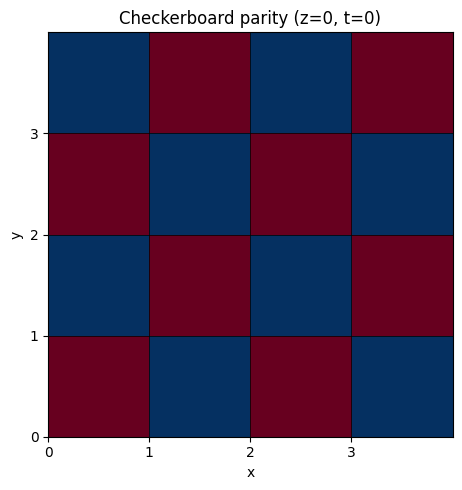

In [7]:
# Visualize a 2D slice (x-y plane at z=0, t=0)
Lx, Ly = La[0], La[1]
grid = np.zeros((Ly, Lx))

for x in range(Lx):
    for y in range(Ly):
        grid[y, x] = su2.parity(np.array([x, y, 0, 0]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(grid, cmap='RdBu', origin='lower', extent=[0, Lx, 0, Ly])
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Checkerboard parity (z=0, t=0)')
ax.set_xticks(range(Lx)); ax.set_yticks(range(Ly))
ax.grid(True, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

Every even site's nearest neighbors are all odd, and vice versa.
This bipartite structure allows the Dirac operator to be block-decomposed:
$$D = \begin{pmatrix} M_{ee} & D_{eo} \\ D_{oe} & M_{oo} \end{pmatrix}$$

## Exercises

1. Change `La` to `[6, 6, 6, 20]` or `[2, 2, 2, 2]` and re-run the cells in
   Section 1. How does the volume change? Compute it by hand first, then verify.

2. For a $6^3 \times 20$ lattice, how many sites are there? How large is the
   Dirac matrix ($8V \times 8V$, where $8 = 2$ colors $\times$ $4$ spins)?

3. Given index $i = 137$ on a $4^4$ lattice, compute the coordinates
   $(x,y,z,t)$ by hand using repeated division:
   $x = i \bmod L_x$, then $i \to \lfloor i / L_x \rfloor$, and repeat
   for $y, z, t$. Verify with `su2.i2p(137, La)`.

4. Starting from the origin, take 4 steps in the $+x$ direction on a $4^4$
   lattice. Where do you end up? **Work it out by hand first** using
   periodic boundary conditions, then verify with `mupi`.

5. On a $4^4$ lattice, site `[3,3,3,3]` sits in the "far corner." What are
   its $+x$, $+y$, $+z$, and $+t$ neighbors? **Work each out by hand**
   using periodic boundary conditions, then verify with `su2.mupi()`.
   Is the corner really far from the origin?

6. Verify that a nearest neighbor of an even site is always odd.

7. **Taxi driver distance**: A taxi driver on a periodic lattice wants to
   maximize their fare — what's the longest distance between two points?
   Write a function to compute the **shortest** periodic distance (in
   lattice units) between two sites. For $(0,0,0,0)$ and $(3,3,3,3)$ on
   a $4^4$ lattice, is the distance $\sqrt{4 \times 3^2}$ or
   $\sqrt{4 \times 1^2}$? *(On a periodic $L = 4$ lattice, coordinate
   distance 3 is really distance 1 the other way — bad news for the
   driver's fare!)*

8. **Asymmetric lattices**: Change `La` to `[4, 4, 4, 8]` and rebuild the
   neighbor tables. How does the volume change? By convention, simulations
   use $L_t > L_s$. Having a longer time direction (or any other direction)
   gives better mass extraction from correlator data.

9. **Memory scaling**: For lattice sizes $L = 4, 8, 16, 32$, compute the
   memory (in MB) needed to store the SU(2) gauge field $U(V, 4, 4)$
   as float64. At what $L$ does this exceed 1 GB?
   (*Formula:* $V \times 4 \times 4 \times 8$ bytes.)